In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

train = pd.read_csv('../data/KDDTrain+.txt', names=columns).drop(columns=['difficulty'])
test  = pd.read_csv('../data/KDDTest+.txt',  names=columns).drop(columns=['difficulty'])

dos   = ['back','land','neptune','pod','smurf','teardrop']
probe = ['ipsweep','nmap','portsweep','satan']
r2l   = ['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster']
u2r   = ['buffer_overflow','loadmodule','perl','rootkit']

def map_label(label):
    if label == 'normal': return 'normal'
    if label in dos:      return 'DoS'
    if label in probe:    return 'Probe'
    if label in r2l:      return 'R2L'
    if label in u2r:      return 'U2R'
    return 'zero-day'

# Keep zero-day in test for simulation — that's the point
train_clean = train[train['label'].apply(map_label) != 'zero-day'].copy()
train_clean['label'] = train_clean['label'].apply(map_label)
test['label']        = test['label'].apply(map_label)

cat_cols = ['protocol_type', 'service', 'flag']
le_feat  = LabelEncoder()
for col in cat_cols:
    combined = pd.concat([train_clean[col], test[col]])
    le_feat.fit(combined)
    train_clean[col] = le_feat.transform(train_clean[col])
    test[col]        = le_feat.transform(test[col])

le_label = LabelEncoder()
le_label.fit(train_clean['label'])
train_clean['label'] = le_label.transform(train_clean['label'])

feature_names = [c for c in train_clean.columns if c != 'label']
class_names   = list(le_label.classes_)

X_train = train_clean[feature_names]
y_train = train_clean['label']
X_test  = test[feature_names]
y_test_families = test['label']  # keep string labels for simulation

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# SMOTE + XGBoost
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

xgb = XGBClassifier(n_estimators=100, random_state=42,
                    eval_metric='mlogloss', n_jobs=-1)
xgb.fit(X_res, y_res)

# Autoencoder on normal only
normal_mask    = (y_train == le_label.transform(['normal'])[0])
X_train_normal = X_train_scaled[normal_mask]

input_dim = X_train_normal.shape[1]
inputs    = Input(shape=(input_dim,))
x = Dense(32, activation='relu')(inputs)
x = Dropout(0.1)(x)
x = Dense(16, activation='relu')(x)
x = Dropout(0.1)(x)
encoded = Dense(12, activation='relu')(x)
x = Dense(16, activation='relu')(encoded)
x = Dropout(0.1)(x)
x = Dense(32, activation='relu')(x)
decoded = Dense(input_dim, activation='linear')(x)

autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')
autoencoder.fit(X_train_normal, X_train_normal,
                epochs=200, batch_size=512, validation_split=0.1,
                callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                                         restore_best_weights=True)],
                verbose=0)

# Set threshold at 80th percentile
train_recon = autoencoder.predict(X_train_normal, verbose=0)
train_mse   = np.mean(np.power(X_train_normal - train_recon, 2), axis=1)
ae_threshold = np.percentile(train_mse, 80)

print("Both models ready")
print(f"XGBoost classes: {class_names}")
print(f"Autoencoder threshold: {ae_threshold:.6f}")

Both models ready
XGBoost classes: ['DoS', 'Probe', 'R2L', 'U2R', 'normal']
Autoencoder threshold: 0.081436


In [2]:
def run_pipeline(connection, scaler, xgb, autoencoder, ae_threshold,
                 le_label, class_names, feature_names):
    """
    Two-layer IDS pipeline for a single connection:
    Layer 1: Autoencoder — is this anomalous at all?
    Layer 2: XGBoost    — if anomalous, what kind of attack?
    """
    x = scaler.transform(connection[feature_names].values)

    # Layer 1 — Autoencoder anomaly score
    recon     = autoencoder.predict(x, verbose=0)
    mse       = np.mean(np.power(x - recon, 2), axis=1)[0]
    is_anomaly = mse > ae_threshold

    # Layer 2 — XGBoost classification
    xgb_pred  = xgb.predict(x)[0]
    xgb_label = class_names[xgb_pred]
    xgb_proba = xgb.predict_proba(x)[0]
    confidence = xgb_proba.max()

    return {
        'anomaly_score': round(float(mse), 6),
        'is_anomaly':    bool(is_anomaly),
        'xgb_label':     xgb_label,
        'confidence':    round(float(confidence), 3),
        'alert_level':   _get_alert(is_anomaly, xgb_label, confidence)
    }

def _get_alert(is_anomaly, xgb_label, confidence):
    if xgb_label == 'normal' and not is_anomaly:
        return 'CLEAR'
    if xgb_label == 'normal' and is_anomaly:
        return 'SUSPICIOUS'       # autoencoder flagged, XGBoost missed — zero-day candidate
    if xgb_label != 'normal' and confidence > 0.8:
        return 'HIGH ALERT'
    return 'ALERT'

print("Pipeline function ready")

Pipeline function ready


In [3]:
# Sample 200 connections from test — mix of all families
sample_idx = (test.groupby('label', group_keys=False)
              .apply(lambda x: x.sample(min(40, len(x)), random_state=42))
              .index)
stream = test.loc[sample_idx].reset_index(drop=True)

print(f"Simulating {len(stream)} live connections...")
print(f"Family breakdown:\n{stream['label'].value_counts()}\n")

results = []
for i, row in stream.iterrows():
    connection = pd.DataFrame([row])
    true_label = connection['label'].values[0]
    result     = run_pipeline(connection, scaler, xgb, autoencoder,
                               ae_threshold, le_label, class_names, feature_names)
    result['true_label'] = true_label
    result['index']      = i
    results.append(result)

results_df = pd.DataFrame(results)
print("Simulation complete")
print(f"\nAlert distribution:\n{results_df['alert_level'].value_counts()}")

Simulating 237 live connections...
Family breakdown:
label
DoS         40
Probe       40
R2L         40
normal      40
zero-day    40
U2R         37
Name: count, dtype: int64

Simulation complete

Alert distribution:
alert_level
HIGH ALERT    103
SUSPICIOUS     69
CLEAR          51
ALERT          14
Name: count, dtype: int64


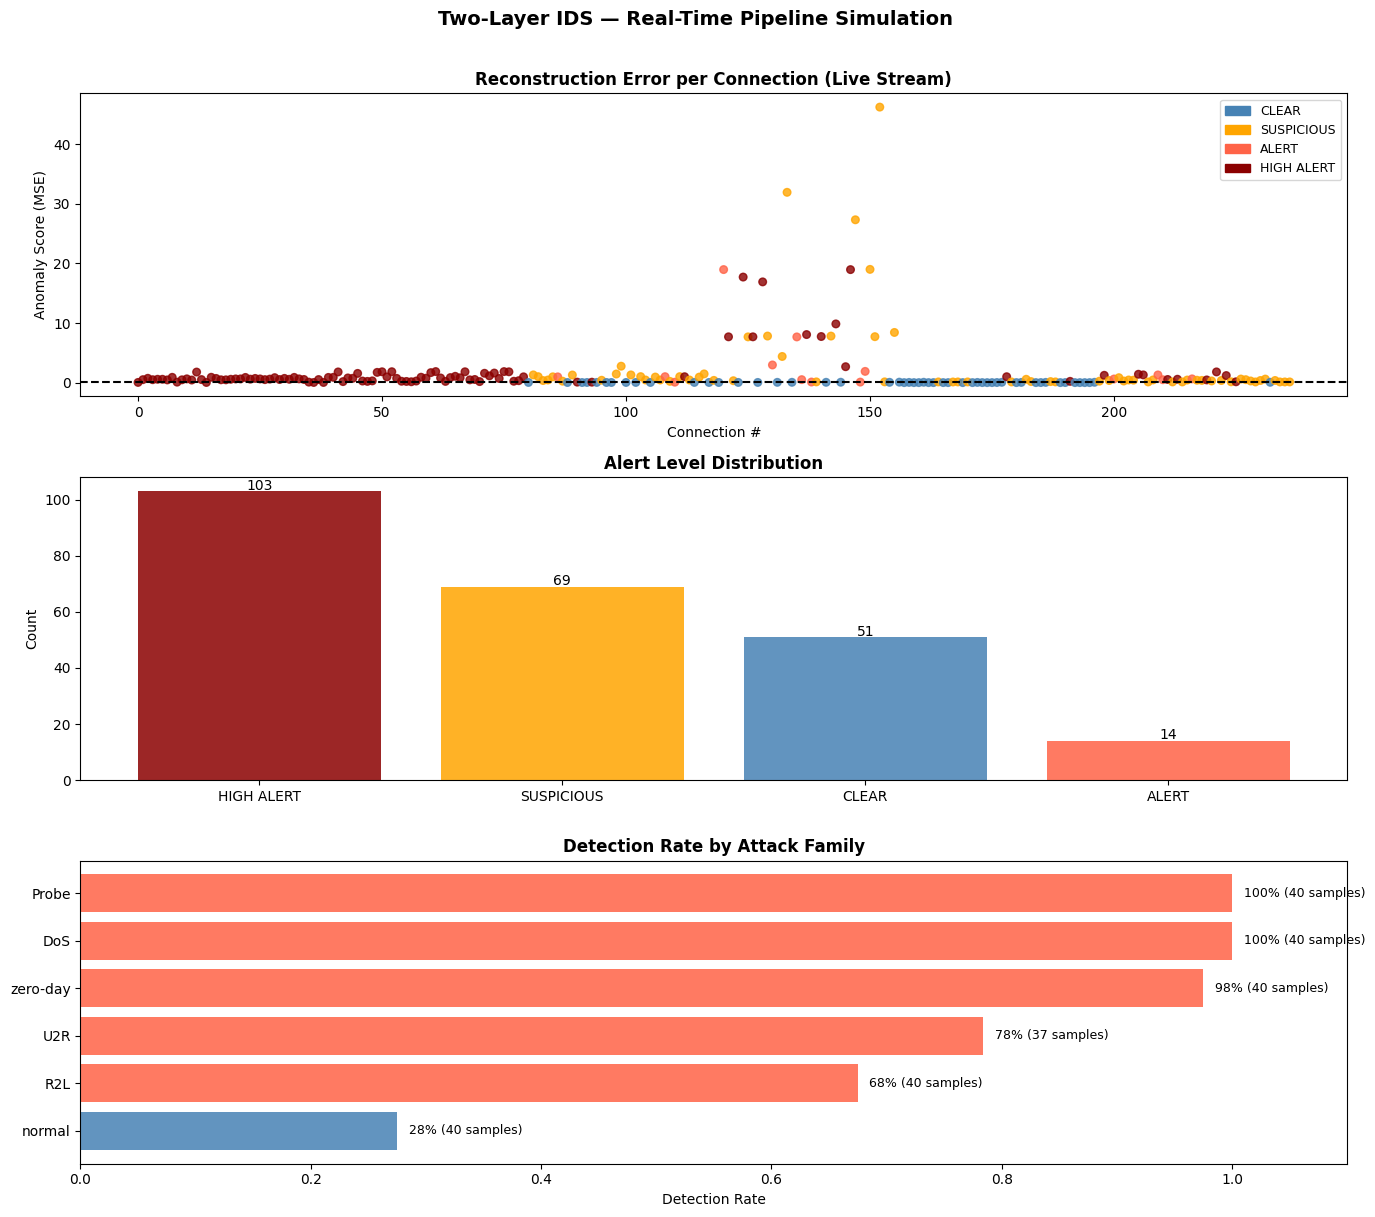

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1 — Anomaly score over time
colors_map = {'CLEAR': 'steelblue', 'SUSPICIOUS': 'orange',
              'ALERT': 'tomato', 'HIGH ALERT': 'darkred'}
point_colors = results_df['alert_level'].map(colors_map)

axes[0].scatter(results_df['index'], results_df['anomaly_score'],
                c=point_colors, s=30, alpha=0.8)
axes[0].axhline(ae_threshold, color='black', linestyle='--',
                linewidth=1.5, label=f'Threshold = {ae_threshold:.4f}')
axes[0].set_title('Reconstruction Error per Connection (Live Stream)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Anomaly Score (MSE)')
axes[0].set_xlabel('Connection #')
axes[0].legend()

legend_patches = [mpatches.Patch(color=v, label=k)
                  for k, v in colors_map.items()]
axes[0].legend(handles=legend_patches, loc='upper right', fontsize=9)

# Plot 2 — Alert level distribution
alert_counts = results_df['alert_level'].value_counts()
bar_colors   = [colors_map[a] for a in alert_counts.index]
axes[1].bar(alert_counts.index, alert_counts.values,
            color=bar_colors, alpha=0.85)
axes[1].set_title('Alert Level Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
for i, (label, val) in enumerate(zip(alert_counts.index, alert_counts.values)):
    axes[1].text(i, val + 0.5, str(val), ha='center', fontsize=10)

# Plot 3 — Detection by true family
families = stream['label'].unique()
family_stats = []
for family in families:
    mask       = results_df['true_label'] == family
    total      = mask.sum()
    detected   = (results_df[mask]['alert_level'] != 'CLEAR').sum()
    family_stats.append({'family': family, 'total': total, 'detected': detected,
                         'rate': detected/total if total > 0 else 0})

fs_df = pd.DataFrame(family_stats).sort_values('rate', ascending=True)
bar_cols = ['steelblue' if f == 'normal' else 'tomato' for f in fs_df['family']]
axes[2].barh(fs_df['family'], fs_df['rate'], color=bar_cols, alpha=0.85)
axes[2].set_xlim(0, 1.1)
axes[2].set_title('Detection Rate by Attack Family', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Detection Rate')
for i, (rate, total) in enumerate(zip(fs_df['rate'], fs_df['total'])):
    axes[2].text(rate + 0.01, i, f'{rate:.0%} ({total} samples)',
                 va='center', fontsize=9)

plt.suptitle('Two-Layer IDS — Real-Time Pipeline Simulation',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../realtime_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
print("=" * 75)
print(f"{'#':<5} {'True Label':<12} {'AE Score':<12} {'XGB Label':<12} "
      f"{'Conf.':<8} {'Alert'}")
print("=" * 75)

for _, row in results_df.head(40).iterrows():
    flag = "⚠" if row['alert_level'] != 'CLEAR' else " "
    print(f"{int(row['index']):<5} {row['true_label']:<12} "
          f"{row['anomaly_score']:<12.5f} {row['xgb_label']:<12} "
          f"{row['confidence']:<8.3f} {flag} {row['alert_level']}")

print("=" * 75)

# Zero-day specific analysis
zd_mask = results_df['true_label'] == 'zero-day'
if zd_mask.sum() > 0:
    zd_detected = (results_df[zd_mask]['alert_level'] != 'CLEAR').sum()
    zd_suspicious = (results_df[zd_mask]['alert_level'] == 'SUSPICIOUS').sum()
    print(f"\nZero-day connections: {zd_mask.sum()}")
    print(f"Detected by pipeline: {zd_detected} "
          f"({zd_detected/zd_mask.sum():.1%})")
    print(f"Flagged as SUSPICIOUS (autoencoder only): {zd_suspicious} "
          f"— these would be missed by XGBoost alone")

#     True Label   AE Score     XGB Label    Conf.    Alert
0     DoS          0.03376      DoS          1.000    ⚠ HIGH ALERT
1     DoS          0.49794      DoS          1.000    ⚠ HIGH ALERT
2     DoS          0.72722      DoS          1.000    ⚠ HIGH ALERT
3     DoS          0.49087      DoS          1.000    ⚠ HIGH ALERT
4     DoS          0.56271      DoS          1.000    ⚠ HIGH ALERT
5     DoS          0.56184      DoS          1.000    ⚠ HIGH ALERT
6     DoS          0.45601      DoS          1.000    ⚠ HIGH ALERT
7     DoS          0.88939      DoS          1.000    ⚠ HIGH ALERT
8     DoS          0.08001      DoS          1.000    ⚠ HIGH ALERT
9     DoS          0.47176      DoS          1.000    ⚠ HIGH ALERT
10    DoS          0.63373      DoS          1.000    ⚠ HIGH ALERT
11    DoS          0.43498      DoS          1.000    ⚠ HIGH ALERT
12    DoS          1.77186      DoS          1.000    ⚠ HIGH ALERT
13    DoS          0.51024      DoS          1.000    ⚠ HIGH ALERT
14

In [6]:
total      = len(results_df)
tp         = ((results_df['true_label'] != 'normal') &
              (results_df['alert_level'] != 'CLEAR')).sum()
fp         = ((results_df['true_label'] == 'normal') &
              (results_df['alert_level'] != 'CLEAR')).sum()
tn         = ((results_df['true_label'] == 'normal') &
              (results_df['alert_level'] == 'CLEAR')).sum()
fn         = ((results_df['true_label'] != 'normal') &
              (results_df['alert_level'] == 'CLEAR')).sum()

print("=" * 50)
print("  TWO-LAYER IDS PIPELINE — FINAL SUMMARY")
print("=" * 50)
print(f"  Total connections processed : {total}")
print(f"  True Positives  (caught)    : {tp}")
print(f"  False Positives (false alarm): {fp}")
print(f"  True Negatives  (correct OK): {tn}")
print(f"  False Negatives (missed)    : {fn}")
print(f"  Detection Rate              : {tp/(tp+fn):.1%}")
print(f"  False Alarm Rate            : {fp/(fp+tn):.1%}")
print("=" * 50)
print("\nLayer contributions:")
suspicious = (results_df['alert_level'] == 'SUSPICIOUS').sum()
high_alert = (results_df['alert_level'] == 'HIGH ALERT').sum()
alert      = (results_df['alert_level'] == 'ALERT').sum()
print(f"  XGBoost only    (HIGH ALERT): {high_alert}")
print(f"  XGBoost         (ALERT)     : {alert}")
print(f"  Autoencoder only (SUSPICIOUS): {suspicious} ← zero-day catches")

  TWO-LAYER IDS PIPELINE — FINAL SUMMARY
  Total connections processed : 237
  True Positives  (caught)    : 175
  False Positives (false alarm): 11
  True Negatives  (correct OK): 29
  False Negatives (missed)    : 22
  Detection Rate              : 88.8%
  False Alarm Rate            : 27.5%

Layer contributions:
  XGBoost only    (HIGH ALERT): 103
  XGBoost         (ALERT)     : 14
  Autoencoder only (SUSPICIOUS): 69 ← zero-day catches
